In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Regressão
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Classificação
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [4]:
dados = pd.read_csv("https://raw.githubusercontent.com/MachineTeachingEdu/JAI2025-IA-Educacao/refs/heads/main/02%20-%20An%C3%A1lise%20de%20Dados/dados_final.csv", sep=',')
dados.head()

,Id,nearestBusStop,backwardsCombine,firstAndLast,singlePigLatin,hasTwoDigits,isEvenPositiveInt,isSubstring,helloWorld,doubleX,...,secondHalf,treasureHunt,mostAnagrams,factorial,fibonacci,gcd,listOfLists,friendOfFriends,findTheCircle,Notas
0,S002,0.750,1.0,1.0,0.8,0.833333,1.0,0.333333,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.690317
1,S011,0.875,1.0,1.0,1.0,0.666667,1.0,1.000000,0.8,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.823890
2,S014,0.000,0.0,0.0,0.0,0.000000,0.0,0.000000,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.549519
3,S020,0.750,1.0,1.0,1.0,0.333333,0.0,0.000000,0.8,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.489055
4,S023,0.000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.350000


In [33]:
def seleciona_e_divide(dados, tamanho_do_teste=0.2, reprodutibilidade=False):
  dados = dados[dados['Id'] != 'SA']
  dados_semId = dados.drop(["Id"], axis=1)
  X = dados_semId.drop("Notas", axis=1)
  y = dados_semId["Notas"]
  if not reprodutibilidade:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=tamanho_do_teste)
  else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=tamanho_do_teste, random_state=reprodutibilidade)
  return X_train, y_train, X_test, y_test

def imprime_erro_regressao(model, X_train, y_train, X_test, y_test):
  mae_treino = mean_absolute_error(y_train, model.predict(X_train))
  mae_teste = mean_absolute_error(y_test, model.predict(X_test))
  print("MAE dentro da amostra: ", mae_treino)
  print("MAE fora da amostra: ", mae_teste)

  rmse_treino = root_mean_squared_error(y_train, model.predict(X_train))
  rmse_teste = root_mean_squared_error(y_test, model.predict(X_test))
  print("RMSE dentro da amostra: ", rmse_treino)
  print("RMSE fora da amostra: ", rmse_teste)

def gera_modelos(X_train, y_train, X_test, y_test):
  models = {}

  print("Regressão Linear")
  model = LinearRegression().fit(X_train, y_train)
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  models["regressao"] = model
  print("----------------------------")

  print("kNN")
  model = KNeighborsRegressor().fit(X_train, y_train)
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  models["kNN"] = model
  print("----------------------------")

  print("Árvore de Decisão")
  model = DecisionTreeRegressor(max_depth=8).fit(X_train, y_train)
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  models["arvore"] = model
  print("----------------------------")

  print("Redes Neurais 1")
  model = MLPRegressor(random_state=1).fit(X_train, y_train)
  models["rn1"] = model
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  print("----------------------------")

  print("Redes Neurais 2")
  model = MLPRegressor(random_state=22).fit(X_train, y_train)
  models["rn2"] = model
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  print("----------------------------")

  print("Redes Neurais 3")
  model = MLPRegressor(random_state=11, max_iter=2000).fit(X_train, y_train)
  models["rn3"] = model
  imprime_erro_regressao(model, X_train, y_train, X_test, y_test)
  print("----------------------------")

  return models

In [35]:
X_train, y_train, X_test, y_test = seleciona_e_divide(dados, reprodutibilidade=100)
models = gera_modelos(X_train, y_train, X_test, y_test)

Regressão Linear
MAE dentro da amostra:  0.046854382221263424
MAE fora da amostra:  0.26579348460516766
RMSE dentro da amostra:  0.06382732081900508
RMSE fora da amostra:  0.4132492310640839
----------------------------
kNN
MAE dentro da amostra:  0.07425423912769902
MAE fora da amostra:  0.07313995723635655
RMSE dentro da amostra:  0.12741600866002253
RMSE fora da amostra:  0.11316874499838873
----------------------------
Árvore de Decisão
MAE dentro da amostra:  0.007501001838595821
MAE fora da amostra:  0.06523379147809995
RMSE dentro da amostra:  0.017017260967737032
RMSE fora da amostra:  0.10924814262223775
----------------------------
Redes Neurais 1
MAE dentro da amostra:  0.055803283633929154
MAE fora da amostra:  0.10584206744512221
RMSE dentro da amostra:  0.07024895528180626
RMSE fora da amostra:  0.13009783381909262
----------------------------
Redes Neurais 2
MAE dentro da amostra:  0.04525368350416159
MAE fora da amostra:  0.11232631053364438
RMSE dentro da amostra:  0.0

In [18]:
# Acessar o modelo de regressão linear
model = models["regressao"]

# Obter os nomes das features
feature_names = X_train.columns

# Obter os coeficientes
coefficients = model.coef_

# Criar uma lista de tuplas (coeficiente, nome da feature)
coef_feature_pairs = list(zip(coefficients, feature_names))

# Ordenar a lista pelo valor absoluto do coeficiente em ordem decrescente
coef_feature_pairs_sorted = sorted(coef_feature_pairs, key=lambda x: abs(x[0]), reverse=True)

# Imprimir os coeficientes com os nomes das features
for coef, feature in coef_feature_pairs_sorted:
    print(f"{feature}: {coef}")

treasureHunt: 90.62250915191335
listOfLists: -4.777107244216128
factorial: 2.8542792696572965
gcd: -2.2825590921349765
fibonacci: -1.3209575138225023
middleElement: -1.2183048504296006
secondHalf: 1.0079989996913326
mostAnagrams: -0.8593475895940942
anyLowercase: 0.6024338894755294
createNumberBlock: 0.35350608449909876
doubleX: 0.32250038075390774
sumOfDigits: -0.2864999202470429
castString: -0.2686001664447181
oneToN: 0.2508681483870406
canDrinkAlcohol: 0.24127993507494752
isSubstring: -0.23493264189300447
hasTwoDigits: 0.22610860414669984
stockChange: 0.20557261238354216
firstAndLast: 0.19170833587735128
isEvenPositiveInt: 0.17762157212025484
reduceToPositive: 0.14398555117362277
isPrime: -0.12542724747188924
backwardsCombine: -0.12095932502757419
overNineThousand: -0.11003563899228419
kthDigit: -0.09503989776356606
howManyEggCartons: 0.07467834888270243
raiseToPower: -0.07168178787819489
nearestBusStop: 0.06516108204553908
convertToDegrees: 0.056216745815779796
carefulSquareRoot: 0

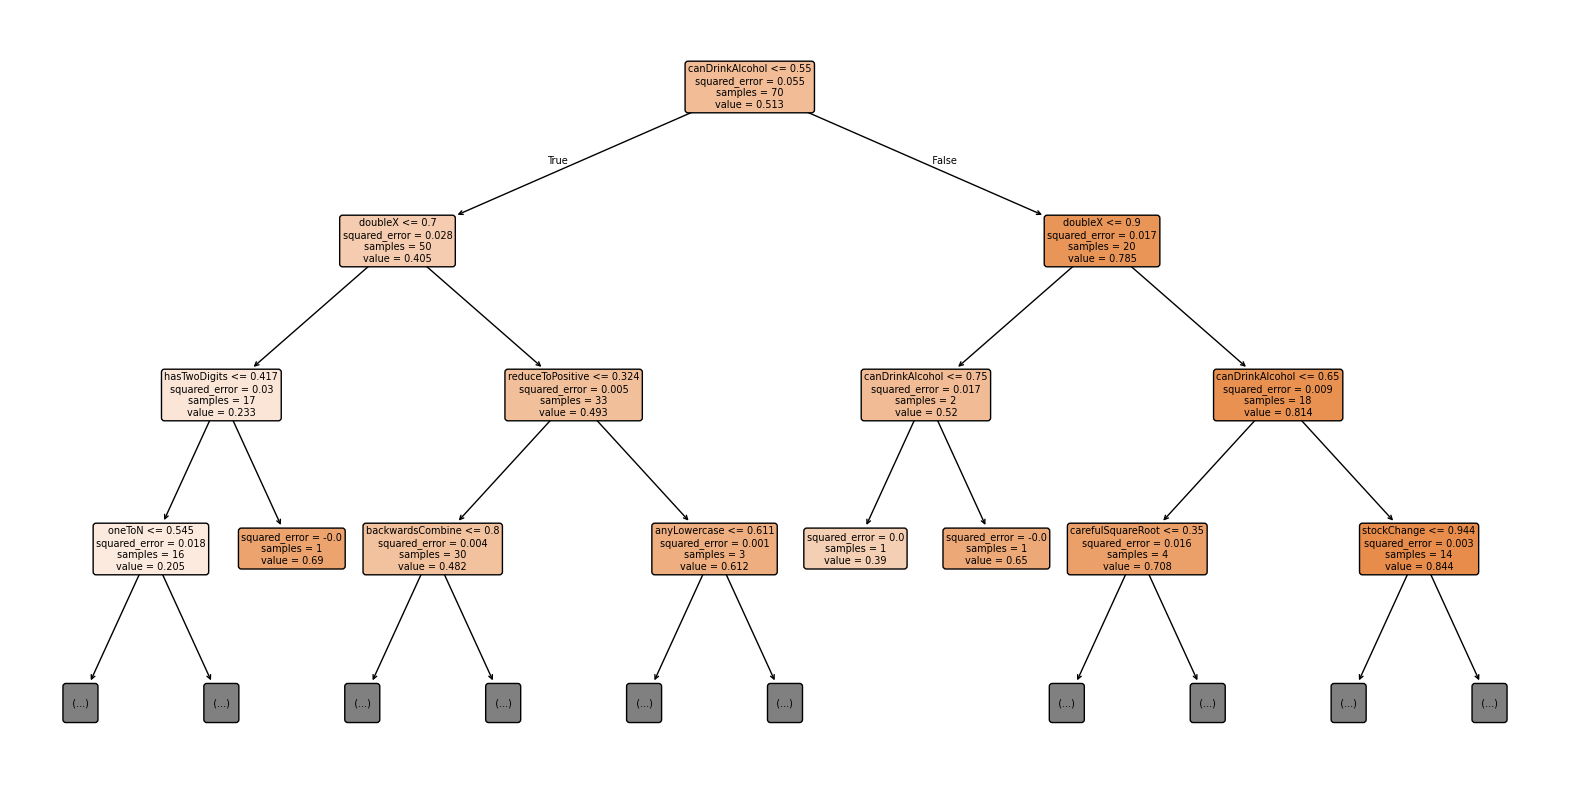

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Acessar o modelo de árvore de decisão
tree_model = models["arvore"]

# Plotar a árvore com profundidade máxima de 5
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X_train.columns, filled=True, rounded=True, max_depth=3)
plt.show()

In [36]:
%pip install shap

  0%|          | 0/18 [00:00<?, ?it/s]

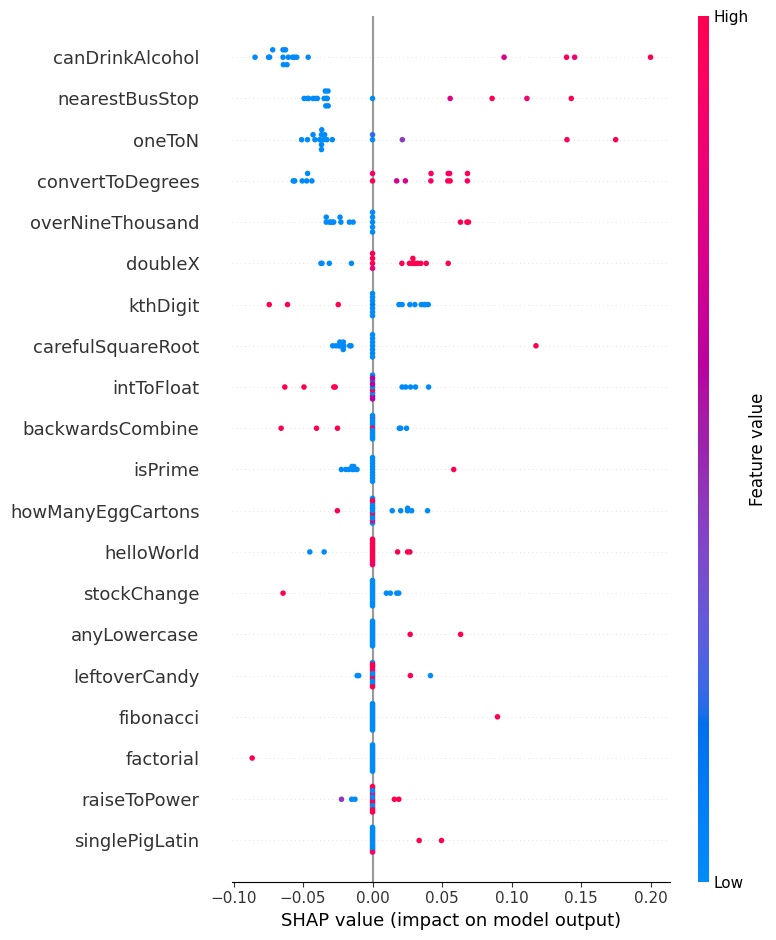

In [43]:
import shap
explainer = shap.KernelExplainer(models['rn3'].predict, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)